In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual aesthetic style
sns.set_theme(style="whitegrid")

# Load the dataset (make sure filename matches your file!)
df = pd.read_csv('C:\\Users\\omp72\\Desktop\\Semantic Duplicate Ques Analysis Project\\data\\quora_ques.csv')  # or '../data/quora_questions_dataset.csv'

print("Dataset Loaded Successfully!")
print("Dataset Shape (Rows, Columns):", df.shape)
df.head(5)

Dataset Loaded Successfully!
Dataset Shape (Rows, Columns): (404351, 6)


,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [12]:
# Check data types and missing values
print("--- Missing Values Count ---")
print(df.isnull().sum())

# Drop any rows with missing questions (NaN values)
df = df.dropna(subset=['question1', 'question2'])
print("\nShape after removing missing values:", df.shape)

--- Missing Values Count ---
id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

Shape after removing missing values: (404348, 6)


Class Counts:
 is_duplicate
0    255042
1    149306
Name: count, dtype: int64

Class Percentages:
 is_duplicate
0    63.074876
1    36.925124
Name: proportion, dtype: float64


C:\Users\omp72\AppData\Local\Temp\ipykernel_27452\2996736679.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='is_duplicate', data=df, palette=['#E63946', '#2A9D8F'])


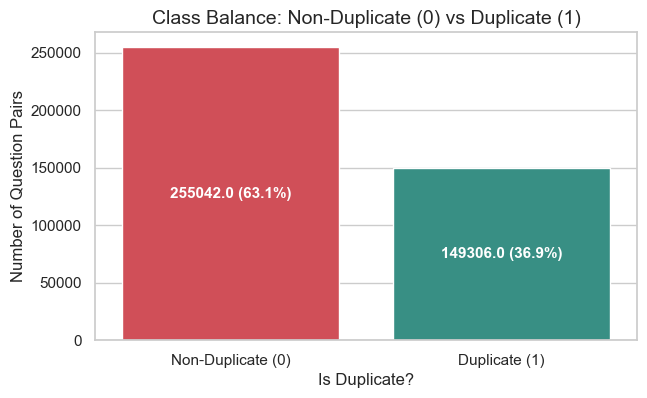

In [13]:
# Calculate counts and percentages for is_duplicate column
class_counts = df['is_duplicate'].value_counts()
class_percent = df['is_duplicate'].value_counts(normalize=True) * 100

print("Class Counts:\n", class_counts)
print("\nClass Percentages:\n", class_percent)

# Plotting the target variable
plt.figure(figsize=(7, 4))
ax = sns.countplot(x='is_duplicate', data=df, palette=['#E63946', '#2A9D8F'])
plt.title("Class Balance: Non-Duplicate (0) vs Duplicate (1)", fontsize=14)
plt.xlabel("Is Duplicate?", fontsize=12)
plt.ylabel("Number of Question Pairs", fontsize=12)
plt.xticks([0, 1], ['Non-Duplicate (0)', 'Duplicate (1)'])

# Add percentage annotations on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height} ({height/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', fontsize=11, color='white', weight='bold')

plt.show()

Average words in Question 1: 10.94
Average words in Question 2: 11.18
Max words in Question 1: 125
Max words in Question 2: 237


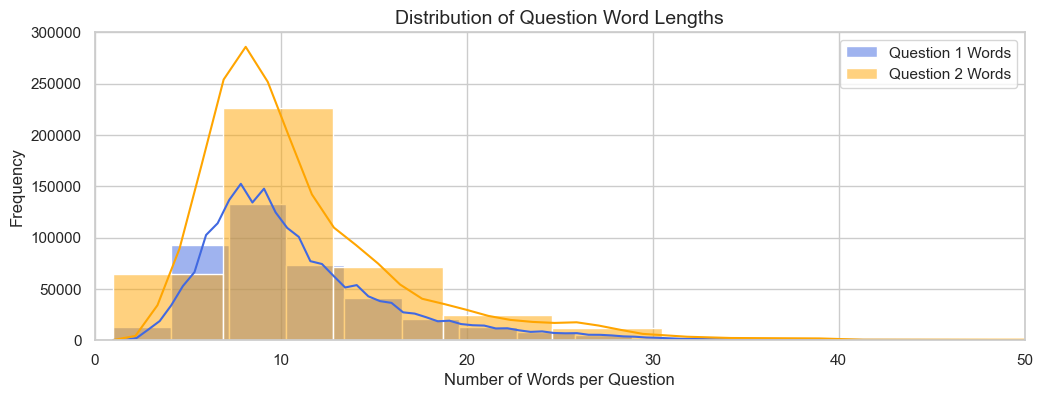

In [14]:
# Calculate word count for question1 and question2
df['q1_words'] = df['question1'].astype(str).apply(lambda s: len(s.split()))
df['q2_words'] = df['question2'].astype(str).apply(lambda s: len(s.split()))

print("Average words in Question 1:", round(df['q1_words'].mean(), 2))
print("Average words in Question 2:", round(df['q2_words'].mean(), 2))
print("Max words in Question 1:", df['q1_words'].max())
print("Max words in Question 2:", df['q2_words'].max())

# Plot Word Count Distribution Histogram
plt.figure(figsize=(12, 4))

sns.histplot(df['q1_words'], bins=40, color='royalblue', label='Question 1 Words', kde=True)
sns.histplot(df['q2_words'], bins=40, color='orange', label='Question 2 Words', kde=True)

plt.xlim(0, 50)
plt.title("Distribution of Question Word Lengths", fontsize=14)
plt.xlabel("Number of Words per Question", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.show()